# Google Merchandise Store Sales & Customer Behaviour Analysis

---

## Author
Aastha Chauhan

## Tools & Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

## Dataset
Google Merchandise Store Dataset

## Project Type
End-to-End Data Analytics Project

---

### Project Overview

This project analyses the Google Merchandise Store dataset to understand customer purchasing behaviour, product performance, sales trends, and customer lifetime value. By cleaning, transforming, and analysing the data, the project aims to generate meaningful business insights that can help improve decision-making, customer engagement, and overall business performance.

The project demonstrates the complete Data Analytics workflow, including data collection, data cleaning, feature engineering, exploratory data analysis (EDA), data visualisation, business insights, and recommendations.

# Table of Contents

1. Introduction

2. Problem Statement

3. Project Objectives

4. About the Dataset

6. Import Libraries

7. Data Loading

8. Data Understanding

9. Data Cleaning

10. Feature Engineering

11. Exploratory Data Analysis (EDA)

12. Business Insights

12. Descriptive Statistics

13. Key Findings

14. Business Recommendations

15. Conclusion

16. Project Limitations

16. Future Scope

#1. Introduction

In today's digital economy, e-commerce businesses generate massive amounts of customer and transaction data every day. Analysing this data helps organisations understand customer behaviour, identify sales trends, improve product performance, and make informed business decisions.

This project focuses on analysing the Google Merchandise Store dataset using Python. The analysis includes data cleaning, feature engineering, exploratory data analysis, and visualisation to uncover valuable insights related to customer purchases, product categories, brands, countries, devices, and customer lifetime value.

The findings of this project can support business decisions related to marketing strategies, inventory planning, customer retention, and revenue growth.

#2. Problem Statement

The Google Merchandise Store collects customer interactions, product information, and transaction records from users across different countries and devices. However, raw data alone cannot provide meaningful business insights.

The objective of this project is to clean, integrate, and analyse the available datasets to identify customer purchasing behaviour, product performance, geographical trends, and revenue patterns. The analysis aims to answer important business questions and provide data-driven recommendations that can help improve customer satisfaction and overall business performance.

#3. Project Objectives

The primary objectives of this project are:

- Analyse customer purchasing behaviour.
- Identify the highest revenue-generating products.
- Evaluate the performance of product categories and brands.
- Analyse customer distribution across different countries.
- Study customer device preferences.
- Analyse customer Lifetime Value (LTV).
- Identify sales trends over time.
- Generate actionable business insights and recommendations.

# 4. About the Dataset

The Google Merchandise Store dataset consists of three related datasets that provide information about customer activities, products, and users.

### Events Dataset
Contains customer interactions such as purchases, session IDs, countries, devices, item IDs, and transaction dates.

### Items Dataset
Contains product-related information including product name, brand, category, variant, and price in USD.

### Users Dataset
Contains user information including user ID, registration date, and customer Lifetime Value (LTV).

These datasets are merged to perform a complete business analysis.

#5. Data Loading

Import Required Libraries

In [46]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

**Upload Files**

In [3]:
from google.colab import files
uploaded = files.upload()

Saving events1.csv to events1 (1).csv
Saving users.csv to users (1).csv
Saving items.csv to items (1).csv


Load Dataset

In [6]:
events = pd.read_csv("events1.csv")
items = pd.read_csv("items.csv")
users = pd.read_csv("users.csv")

#6. Data Understanding

Before performing any analysis, it is important to understand the structure of the datasets. This includes examining the number of rows and columns, data types, missing values, and basic statistical information. Understanding the data helps identify potential quality issues before analysis begins.

In [7]:
print("Events Dataset Shape :", events.shape)
print("Items Dataset Shape :", items.shape)
print("Users Dataset Shape :", users.shape)

Events Dataset Shape : (758884, 7)
Items Dataset Shape : (1381, 6)
Users Dataset Shape : (270154, 3)


In [8]:
events.head()

,user_id,ga_session_id,country,device,type,item_id,date
0,2133,16909,US,mobile,purchase,94,2020-11-01 00:27:14
1,2133,16909,US,mobile,purchase,425,2020-11-01 00:27:14
2,5789,16908,SE,desktop,purchase,1,2020-11-01 01:44:44
3,5789,16908,SE,desktop,purchase,62,2020-11-01 01:44:44
4,5808,4267,US,mobile,add_to_cart,842,2020-11-01 03:06:29


In [9]:
items.head()

,id,name,brand,variant,category,price_in_usd
0,0,Google Land & Sea Cotton Cap,Google,Single Option Only,Apparel,14
1,1,Google KeepCup,Google,Single Option Only,New,28
2,2,Google Land & Sea Nalgene Water Bottle,Google,Single Option Only,Drinkware,20
3,3,Google Unisex Eco Tee Black,Google,LG,Uncategorized Items,22
4,4,Google Chicago Campus Bottle,Google,Single Option Only,Campus Collection,11


In [10]:
users.head()

,id,ltv,date
0,0,0,2020-10-13 05:08:47
1,1,0,2020-11-24 14:26:54
2,2,0,2020-11-24 06:19:54
3,3,231,2020-05-02 11:09:15
4,4,102,2020-11-18 15:54:38


In [11]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 758884 entries, 0 to 758883
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user_id        758884 non-null  int64 
 1   ga_session_id  758884 non-null  int64 
 2   country        754329 non-null  object
 3   device         758884 non-null  object
 4   type           758884 non-null  object
 5   item_id        758884 non-null  int64 
 6   date           758884 non-null  object
dtypes: int64(3), object(4)
memory usage: 40.5+ MB


In [12]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1381 entries, 0 to 1380
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            1381 non-null   int64 
 1   name          1381 non-null   object
 2   brand         1381 non-null   object
 3   variant       973 non-null    object
 4   category      1381 non-null   object
 5   price_in_usd  1381 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 64.9+ KB


In [13]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270154 entries, 0 to 270153
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   id      270154 non-null  int64 
 1   ltv     270154 non-null  int64 
 2   date    270154 non-null  object
dtypes: int64(2), object(1)
memory usage: 6.2+ MB


###Five Point Summary/Statistics of Data

In [14]:
events.describe(include="all")

,user_id,ga_session_id,country,device,type,item_id,date
count,758884.000000,758884.000000,754329,758884,758884,758884.000000,758884
unique,NaN,NaN,108,3,3,NaN,78040
top,NaN,NaN,US,desktop,add_to_cart,NaN,2020-11-19 21:49:59
freq,NaN,NaN,337513,441521,667282,NaN,132
mean,29541.809665,3632.325492,NaN,NaN,NaN,885.629356,NaN
std,55129.337846,3952.875337,NaN,NaN,NaN,289.267126,NaN
min,1.000000,0.000000,NaN,NaN,NaN,0.000000,NaN
25%,8401.000000,625.000000,NaN,NaN,NaN,913.000000,NaN
50%,17181.000000,2103.000000,NaN,NaN,NaN,972.000000,NaN
75%,25809.000000,5365.000000,NaN,NaN,NaN,1040.000000,NaN


In [15]:
items.describe(include="all")

,id,name,brand,variant,category,price_in_usd
count,1381.000000,1381,1381,973,1381,1381.000000
unique,NaN,421,5,44,21,NaN
top,NaN,Google Land & Sea French Terry Sweatshirt,Google,Single Option Only,Apparel,NaN
freq,NaN,14,1166,263,582,NaN
mean,690.000000,NaN,NaN,NaN,NaN,26.322954
std,398.804672,NaN,NaN,NaN,NaN,23.283663
min,0.000000,NaN,NaN,NaN,NaN,1.000000
25%,345.000000,NaN,NaN,NaN,NaN,13.000000
50%,690.000000,NaN,NaN,NaN,NaN,20.000000
75%,1035.000000,NaN,NaN,NaN,NaN,32.000000


In [16]:
users.describe(include="all")

,id,ltv,date
count,270154.000000,270154.000000,270154
unique,NaN,NaN,261362
top,NaN,NaN,1970-01-01 00:00:00
freq,NaN,NaN,4433
mean,135076.500000,1.508865,NaN
std,77986.886649,19.768717,NaN
min,0.000000,0.000000,NaN
25%,67538.250000,0.000000,NaN
50%,135076.500000,0.000000,NaN
75%,202614.750000,0.000000,NaN


#7. Data Cleaning

Data cleaning is one of the most important steps in the data analytics process. Raw datasets often contain missing values, duplicate records, incorrect data types, and inconsistent information that can negatively impact the accuracy of the analysis.

In this section, the datasets are examined to identify and resolve data quality issues before performing exploratory data analysis (EDA). This ensures that the insights generated are reliable and meaningful.

Missing Value

In [17]:
events.isnull().sum()

,0
user_id,0
ga_session_id,0
country,4555
device,0
type,0
item_id,0
date,0


In [18]:
items.isnull().sum()

,0
id,0
name,0
brand,0
variant,408
category,0
price_in_usd,0


In [19]:
users.isnull().sum()

,0
id,0
ltv,0
date,0


###Fill Missing Values

In [20]:
events['country'] = events['country'].fillna('Unknown')

items['variant'] = items['variant'].fillna('Unknown')

### Handling Missing Values

The missing values were analysed before performing any data transformation.

- The **country** column in the Events dataset contained missing values. Since it is a categorical feature, the missing entries were replaced with **"Unknown"** instead of removing the records. This preserves valuable customer activity data while clearly identifying records with unavailable country information.

- The **variant** column in the Items dataset also contained missing values. As this is a categorical attribute describing product variants, the missing values were replaced with **"Unknown"**.

- The Users dataset did not contain any missing values; therefore, no cleaning was required.

This approach maintains data integrity and avoids unnecessary loss of information.

Verify Missing Values

In [21]:
print("Events Dataset")
print(events.isnull().sum())

print("\nItems Dataset")
print(items.isnull().sum())

print("\nUsers Dataset")
print(users.isnull().sum())

Events Dataset
user_id          0
ga_session_id    0
country          0
device           0
type             0
item_id          0
date             0
dtype: int64

Items Dataset
id              0
name            0
brand           0
variant         0
category        0
price_in_usd    0
dtype: int64

Users Dataset
id      0
ltv     0
date    0
dtype: int64


## Duplicate Value Analysis

Duplicate records can lead to inaccurate analysis and misleading business insights. Therefore, all datasets were examined for duplicate entries. If duplicates are found, they will be removed to ensure data consistency and improve the reliability of the analysis.

In [22]:
print("Events Duplicates :", events.duplicated().sum())
print("Items Duplicates :", items.duplicated().sum())
print("Users Duplicates :", users.duplicated().sum())

Events Duplicates : 39498
Items Duplicates : 0
Users Duplicates : 0


## Duplicate Record Validation

Before removing duplicate records, it is important to verify whether they are true duplicate entries or valid repeated business events.

In event-based datasets, repeated records may represent genuine customer activities such as multiple purchases or repeated interactions during different sessions. Therefore, duplicate records should only be removed after careful validation to avoid losing important business information.

In [23]:
# Check exact duplicate rows

duplicate_rows = events[events.duplicated()]

print("Total Duplicate Rows :", duplicate_rows.shape[0])

duplicate_rows.head(10)

Total Duplicate Rows : 39498


,user_id,ga_session_id,country,device,type,item_id,date
13702,20939,16135,IT,desktop,purchase,526,2020-11-18 12:20:09
13703,20939,16135,IT,desktop,purchase,118,2020-11-18 12:20:09
14060,4497,4644,US,mobile,purchase,9,2020-11-18 14:55:50
14061,4497,4644,US,mobile,purchase,213,2020-11-18 14:55:50
14329,4140,9700,US,mobile,purchase,350,2020-11-18 18:08:56
14330,4140,9700,US,mobile,purchase,464,2020-11-18 18:08:56
14331,4140,9700,US,mobile,purchase,212,2020-11-18 18:08:56
14357,15847,17070,IN,mobile,purchase,558,2020-11-18 18:13:23
14732,30758,17071,SG,mobile,purchase,16,2020-11-18 19:08:49
14839,1417,17067,US,mobile,purchase,124,2020-11-18 19:29:20


## Duplicate Value Treatment

After validating the duplicate records, it was observed that the Events dataset contained 39,498 exact duplicate rows across all columns. Since these records represented duplicated information rather than unique customer events, they were removed to improve data quality and prevent biased analytical results.

The Items and Users datasets did not contain any duplicate records, so no changes were required.

In [24]:
# Remove duplicate rows
events.drop_duplicates(inplace=True)

# Verify duplicates after removal
print("Events Duplicates :", events.duplicated().sum())
print("Items Duplicates :", items.duplicated().sum())
print("Users Duplicates :", users.duplicated().sum())

Events Duplicates : 0
Items Duplicates : 0
Users Duplicates : 0


In [25]:
print("Events Shape :", events.shape)
print("Items Shape :", items.shape)
print("Users Shape :", users.shape)

Events Shape : (719386, 7)
Items Shape : (1381, 6)
Users Shape : (270154, 3)


## Data Cleaning Summary

The datasets were cleaned to ensure high-quality analysis.

- Missing values in the **country** column were replaced with **"Unknown"**.
- Missing values in the **variant** column were replaced with **"Unknown"**.
- Exact duplicate records were removed from the Events dataset.
- The Items and Users datasets contained no duplicate records.

These preprocessing steps improved the consistency and reliability of the datasets before further analysis.

#8. Data Preprocessing

Data preprocessing prepares the cleaned datasets for analysis by converting data into a suitable format and combining multiple tables.

In this project, the preprocessing stage includes:

- Converting the transaction date into datetime format.
- Merging the Events, Items, and Users datasets.
- Creating new date-related features such as Year, Month, Day, Quarter, and Week Number.
- Preparing the final analytical dataset for Exploratory Data Analysis (EDA).

These transformations improve the quality of the analysis and enable meaningful business insights.

Convert Date

In [26]:
# Convert date columns to datetime format

events['date'] = pd.to_datetime(events['date'])

users['date'] = pd.to_datetime(users['date'])

print(events['date'].dtype)
print(users['date'].dtype)

datetime64[ns]
datetime64[ns]


## Why Date Conversion?

The original date columns were stored as text. Converting them into datetime format allows extraction of useful time-based features such as month, year, weekday, and quarter, which are essential for trend analysis.

Merge Dataset

In [27]:
# Merge Events with Items
merged_df = pd.merge(
    events,
    items,
    left_on='item_id',
    right_on='id',
    how='left'
)
# Merge with Users
merged_df = pd.merge(
    merged_df,
    users,
    left_on='user_id',
    right_on='id',
    how='left',
    suffixes=('', '_user')
)
print("Merged Dataset Shape:", merged_df.shape)
merged_df.head()

Merged Dataset Shape: (719386, 16)


,user_id,ga_session_id,country,device,type,item_id,date,id,name,brand,variant,category,price_in_usd,id_user,ltv,date_user
0,2133,16909,US,mobile,purchase,94,2020-11-01 00:27:14,94,Google Large Tote White,Google,Single Option Only,Bags,10,2133,34,2020-11-01 00:09:55
1,2133,16909,US,mobile,purchase,425,2020-11-01 00:27:14,425,Google Heather Green Speckled Tee,Google,XL,Apparel,21,2133,34,2020-11-01 00:09:55
2,5789,16908,SE,desktop,purchase,1,2020-11-01 01:44:44,1,Google KeepCup,Google,Single Option Only,New,28,5789,72,2020-10-14 00:26:03
3,5789,16908,SE,desktop,purchase,62,2020-11-01 01:44:44,62,Google Mini Kick Ball,Google,Single Option Only,Fun,2,5789,72,2020-10-14 00:26:03
4,5808,4267,US,mobile,add_to_cart,842,2020-11-01 03:06:29,842,Google Infant Hero Onesie Grey,Google,Unknown,Apparel,25,5808,0,2020-08-18 03:44:52


## Dataset Integration

The three datasets were combined using common identifiers.

- The Events dataset was merged with the Items dataset using the product identifier.
- The resulting dataset was then merged with the Users dataset using the customer identifier.

This created a single consolidated dataset containing customer, product, and transaction information, enabling comprehensive business analysis.

In [28]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 719386 entries, 0 to 719385
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   user_id        719386 non-null  int64         
 1   ga_session_id  719386 non-null  int64         
 2   country        719386 non-null  object        
 3   device         719386 non-null  object        
 4   type           719386 non-null  object        
 5   item_id        719386 non-null  int64         
 6   date           719386 non-null  datetime64[ns]
 7   id             719386 non-null  int64         
 8   name           719386 non-null  object        
 9   brand          719386 non-null  object        
 10  variant        719386 non-null  object        
 11  category       719386 non-null  object        
 12  price_in_usd   719386 non-null  int64         
 13  id_user        719386 non-null  int64         
 14  ltv            719386 non-null  int64         
 15  

#9. Feature Engineering

Feature engineering is the process of creating new variables from existing data to improve analysis.

The following features were created:

- **Year** – Identifies the transaction year.
- **Month** – Helps analyse monthly sales trends.
- **Month Number** – Used for chronological sorting.
- **Day** – Analyses customer activity by weekday.
- **Week Number** – Enables weekly trend analysis.
- **Quarter** – Supports quarterly business reporting.

These engineered features allow deeper exploration of seasonal trends and customer purchasing behaviour.

In [29]:
# Create Date Features
merged_df['Year'] = merged_df['date'].dt.year
merged_df['Month'] = merged_df['date'].dt.month_name()
merged_df['Month_Number'] = merged_df['date'].dt.month
merged_df['Day'] = merged_df['date'].dt.day_name()
merged_df['Week_Number'] = merged_df['date'].dt.isocalendar().week.astype(int)
merged_df['Quarter'] = merged_df['date'].dt.quarter

merged_df.head()

,user_id,ga_session_id,country,device,type,item_id,date,id,name,brand,variant,category,price_in_usd,id_user,ltv,date_user,Year,Month,Month_Number,Day,Week_Number,Quarter
0,2133,16909,US,mobile,purchase,94,2020-11-01 00:27:14,94,Google Large Tote White,Google,Single Option Only,Bags,10,2133,34,2020-11-01 00:09:55,2020,November,11,Sunday,44,4
1,2133,16909,US,mobile,purchase,425,2020-11-01 00:27:14,425,Google Heather Green Speckled Tee,Google,XL,Apparel,21,2133,34,2020-11-01 00:09:55,2020,November,11,Sunday,44,4
2,5789,16908,SE,desktop,purchase,1,2020-11-01 01:44:44,1,Google KeepCup,Google,Single Option Only,New,28,5789,72,2020-10-14 00:26:03,2020,November,11,Sunday,44,4
3,5789,16908,SE,desktop,purchase,62,2020-11-01 01:44:44,62,Google Mini Kick Ball,Google,Single Option Only,Fun,2,5789,72,2020-10-14 00:26:03,2020,November,11,Sunday,44,4
4,5808,4267,US,mobile,add_to_cart,842,2020-11-01 03:06:29,842,Google Infant Hero Onesie Grey,Google,Unknown,Apparel,25,5808,0,2020-08-18 03:44:52,2020,November,11,Sunday,44,4


In [30]:
print("Final Dataset Shape:", merged_df.shape)

merged_df.head()

Final Dataset Shape: (719386, 22)


,user_id,ga_session_id,country,device,type,item_id,date,id,name,brand,variant,category,price_in_usd,id_user,ltv,date_user,Year,Month,Month_Number,Day,Week_Number,Quarter
0,2133,16909,US,mobile,purchase,94,2020-11-01 00:27:14,94,Google Large Tote White,Google,Single Option Only,Bags,10,2133,34,2020-11-01 00:09:55,2020,November,11,Sunday,44,4
1,2133,16909,US,mobile,purchase,425,2020-11-01 00:27:14,425,Google Heather Green Speckled Tee,Google,XL,Apparel,21,2133,34,2020-11-01 00:09:55,2020,November,11,Sunday,44,4
2,5789,16908,SE,desktop,purchase,1,2020-11-01 01:44:44,1,Google KeepCup,Google,Single Option Only,New,28,5789,72,2020-10-14 00:26:03,2020,November,11,Sunday,44,4
3,5789,16908,SE,desktop,purchase,62,2020-11-01 01:44:44,62,Google Mini Kick Ball,Google,Single Option Only,Fun,2,5789,72,2020-10-14 00:26:03,2020,November,11,Sunday,44,4
4,5808,4267,US,mobile,add_to_cart,842,2020-11-01 03:06:29,842,Google Infant Hero Onesie Grey,Google,Unknown,Apparel,25,5808,0,2020-08-18 03:44:52,2020,November,11,Sunday,44,4


#10. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of examining and visualising data to discover patterns, trends, and relationships.

The objective of this section is to answer key business questions related to customer behaviour, product performance, revenue distribution, and geographical trends using appropriate visualisations.

In [31]:
purchase_df = merged_df[merged_df['type'] == 'purchase'].copy()
purchase_df.shape

(14711, 22)

In [32]:
purchase_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14711 entries, 0 to 715903
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   user_id        14711 non-null  int64         
 1   ga_session_id  14711 non-null  int64         
 2   country        14711 non-null  object        
 3   device         14711 non-null  object        
 4   type           14711 non-null  object        
 5   item_id        14711 non-null  int64         
 6   date           14711 non-null  datetime64[ns]
 7   id             14711 non-null  int64         
 8   name           14711 non-null  object        
 9   brand          14711 non-null  object        
 10  variant        14711 non-null  object        
 11  category       14711 non-null  object        
 12  price_in_usd   14711 non-null  int64         
 13  id_user        14711 non-null  int64         
 14  ltv            14711 non-null  int64         
 15  date_user      14711 no

In [33]:
purchase_df.head()

,user_id,ga_session_id,country,device,type,item_id,date,id,name,brand,variant,category,price_in_usd,id_user,ltv,date_user,Year,Month,Month_Number,Day,Week_Number,Quarter
0,2133,16909,US,mobile,purchase,94,2020-11-01 00:27:14,94,Google Large Tote White,Google,Single Option Only,Bags,10,2133,34,2020-11-01 00:09:55,2020,November,11,Sunday,44,4
1,2133,16909,US,mobile,purchase,425,2020-11-01 00:27:14,425,Google Heather Green Speckled Tee,Google,XL,Apparel,21,2133,34,2020-11-01 00:09:55,2020,November,11,Sunday,44,4
2,5789,16908,SE,desktop,purchase,1,2020-11-01 01:44:44,1,Google KeepCup,Google,Single Option Only,New,28,5789,72,2020-10-14 00:26:03,2020,November,11,Sunday,44,4
3,5789,16908,SE,desktop,purchase,62,2020-11-01 01:44:44,62,Google Mini Kick Ball,Google,Single Option Only,Fun,2,5789,72,2020-10-14 00:26:03,2020,November,11,Sunday,44,4
52,20120,17424,CA,desktop,purchase,423,2020-11-01 04:11:11,423,Android Iconic Backpack,Android,Single Option Only,New,25,20120,25,2020-11-01 04:01:10,2020,November,11,Sunday,44,4


### Business Question 1

### How did daily revenue change over time?

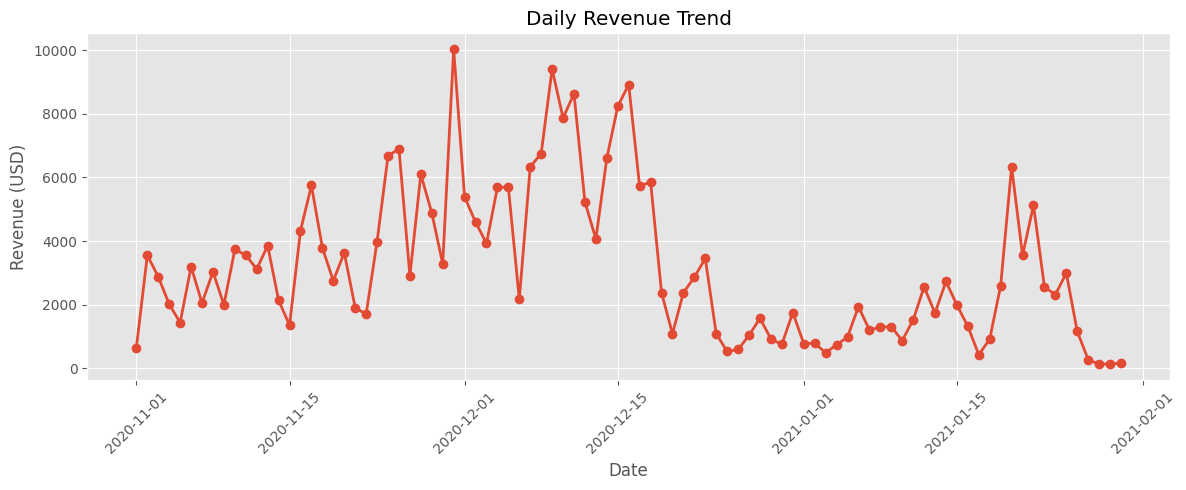

In [34]:
# Create a new column with only the date
purchase_df['Only_Date'] = purchase_df['date'].dt.date
daily_sales = (
    purchase_df.groupby('Only_Date')['price_in_usd']
    .sum()
    .reset_index()
)
plt.figure(figsize=(12,5))
plt.plot(
    daily_sales['Only_Date'],
    daily_sales['price_in_usd'],
    marker='o',
    linewidth=2
)
plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Observation

The chart displays the total revenue generated each day during the analysis period.

### Business Insight

The daily revenue trend highlights fluctuations in customer purchases over time. Identifying days with higher revenue can help businesses schedule promotional campaigns, optimise inventory levels, and improve operational planning.

### Business Question 2

### What is the monthly revenue trend?


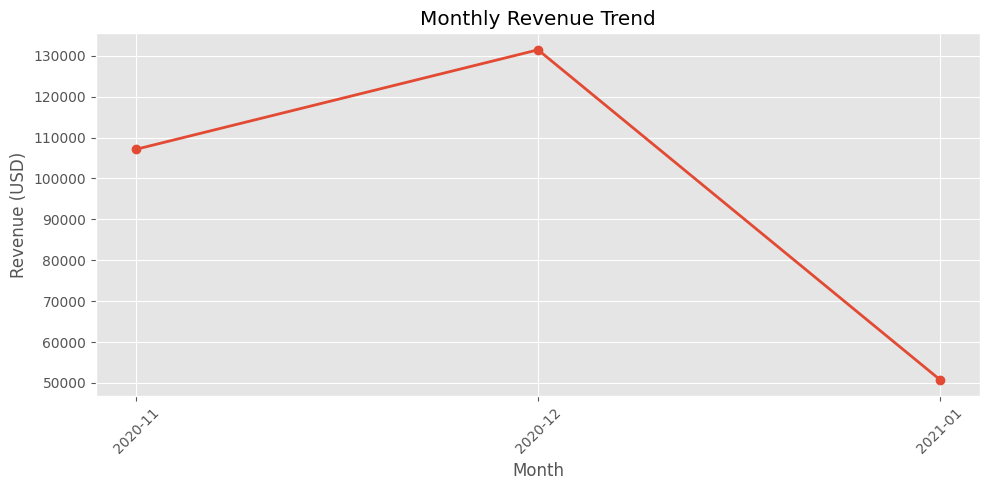

In [35]:
# Create Month-Year column
purchase_df['Month_Year'] = purchase_df['date'].dt.to_period('M').astype(str)

# Monthly Revenue
monthly_sales = (
    purchase_df.groupby('Month_Year')['price_in_usd'].sum().reset_index()
)
plt.figure(figsize=(10,5))
plt.plot(
    monthly_sales['Month_Year'],
    monthly_sales['price_in_usd'],
    marker='o',
    linewidth=2
)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (USD)")

plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The monthly revenue trend shows that sales fluctuate across different months. Some months generate higher revenue than others, indicating changes in customer purchasing behaviour.

### Business Insight

The business can use high-performing months to plan promotional campaigns and optimise inventory during periods of increased demand.

### Business Question 3

### Which products generate the highest revenue?


*   Top 10 Products by Revenue




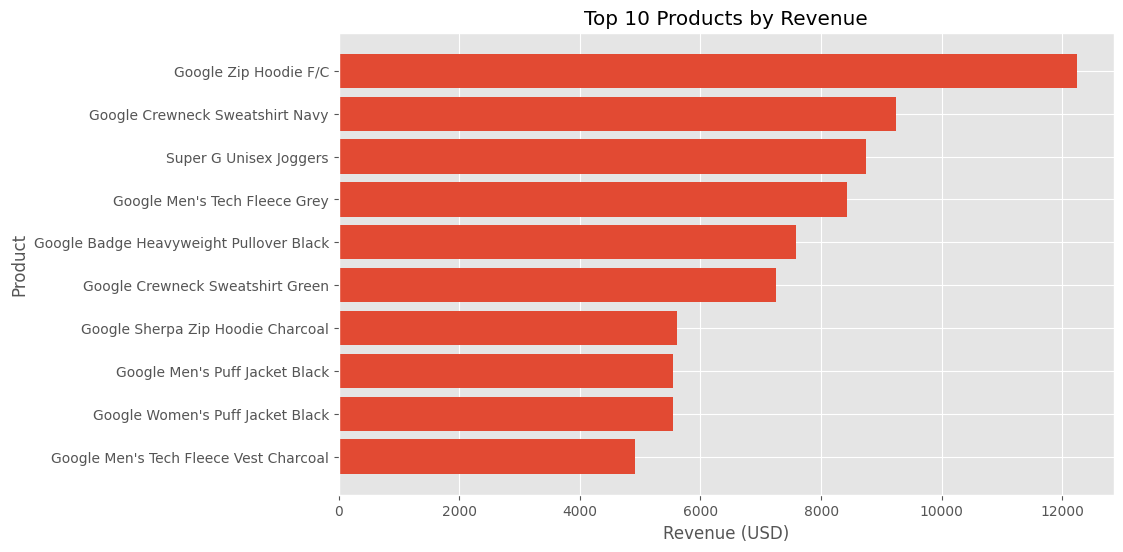

In [36]:
top_products = (
    purchase_df.groupby('name')['price_in_usd']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(10,6))
plt.barh(top_products.index, top_products.values)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (USD)")
plt.ylabel("Product")
plt.gca().invert_yaxis()

plt.show()

### Observation

A small number of products contribute significantly to the overall revenue, while the remaining products generate comparatively lower sales.

### Business Insight

The company should focus on promoting and maintaining sufficient inventory for high-performing products to maximise revenue.

### Business Question 4

### Which product categories generate the highest revenue?

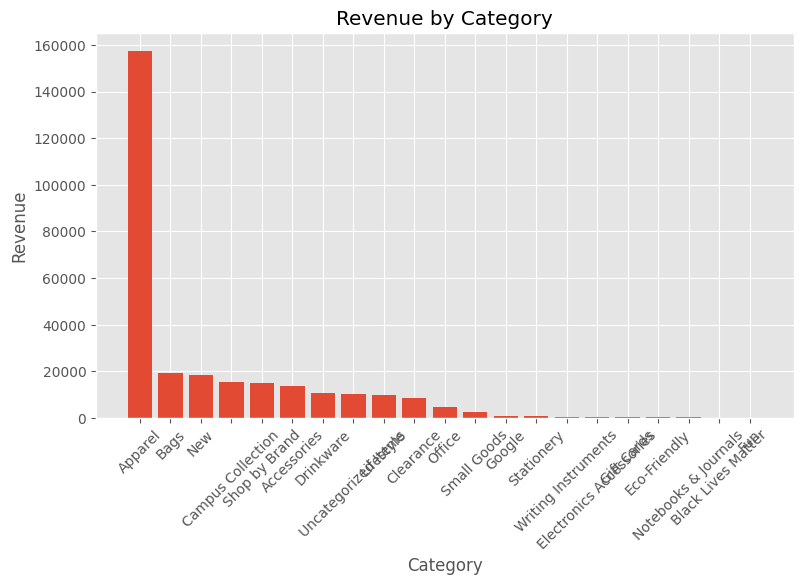

In [37]:
category_sales = (
    purchase_df.groupby('category')['price_in_usd']
    .sum()
    .sort_values(ascending=False)
)
plt.figure(figsize=(9,5))
plt.bar(category_sales.index, category_sales.values)
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

### Business Question 5

### Which device is most commonly used for purchases?

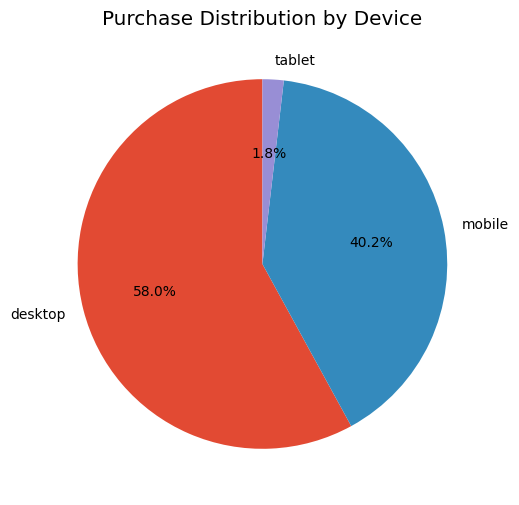

In [38]:
device = purchase_df['device'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(
    device,
    labels=device.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Purchase Distribution by Device")
plt.show()

### Observation

Customers use different devices to make purchases, Desktop device contributing the highest share of transactions.

### Business Insight

Optimising the shopping experience for the most frequently used device can improve customer satisfaction and increase conversions.

### Business Question 6

###Which countries have the highest number of purchases?

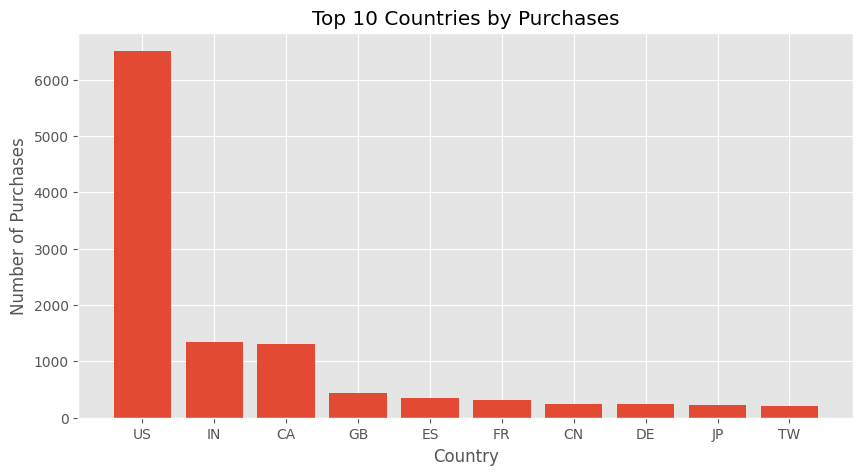

In [39]:
country = purchase_df['country'].value_counts().head(10)
plt.figure(figsize=(10,5))
plt.bar(country.index, country.values)

plt.title("Top 10 Countries by Purchases")
plt.xlabel("Country")
plt.ylabel("Number of Purchases")

plt.show()

### Observation

US Country has the highest number of purchases, while other regions contribute a smaller share of total transactions.

### Business Insight

The company can strengthen its presence in high-performing countries and explore growth opportunities in underperforming regions.

### Business Question 7

### Which brands generate the highest revenue?

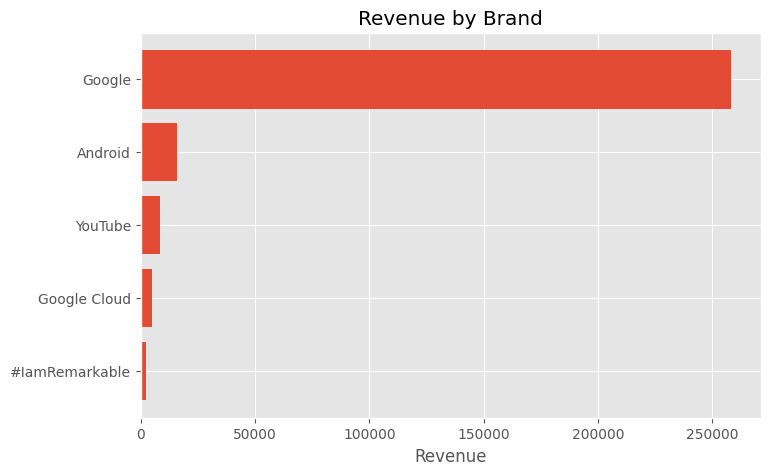

In [40]:
brand = (
    purchase_df.groupby('brand')['price_in_usd']
    .sum()
    .sort_values(ascending=False)
)
plt.figure(figsize=(8,5))
plt.barh(brand.index, brand.values)
plt.title("Revenue by Brand")
plt.xlabel("Revenue")
plt.gca().invert_yaxis()

plt.show()

### Observation

Google brand generate significantly higher revenue compared to others, indicating differences in customer demand.

### Business Insight

High-performing brands should receive greater marketing support, while low-performing brands can be reviewed for improvement opportunities.

### Business Question 8

### How are product prices distributed?

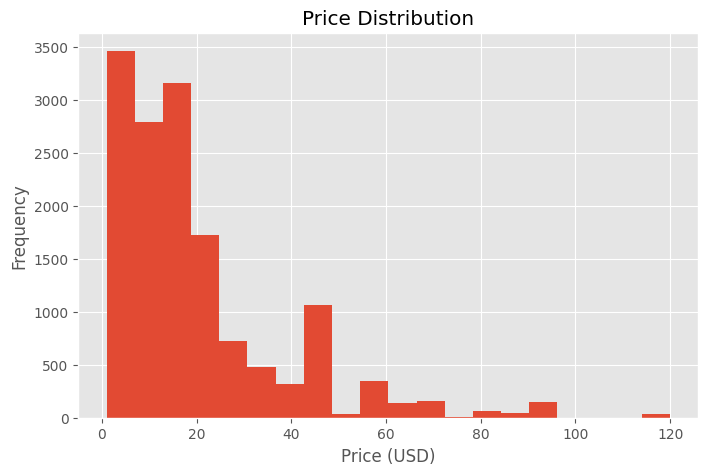

In [41]:
plt.figure(figsize=(8,5))
plt.hist(
    purchase_df['price_in_usd'],
    bins=20
)
plt.title("Price Distribution")
plt.xlabel("Price (USD)")
plt.ylabel("Frequency")

plt.show()

### Observation

Most products fall within a specific price range, while only a few products have relatively high prices.

### Business Insight

Understanding customer preferences across different price ranges can help optimise pricing strategies and product offerings.

### Business Question 9

### What is the distribution of customer lifetime value (LTV)?

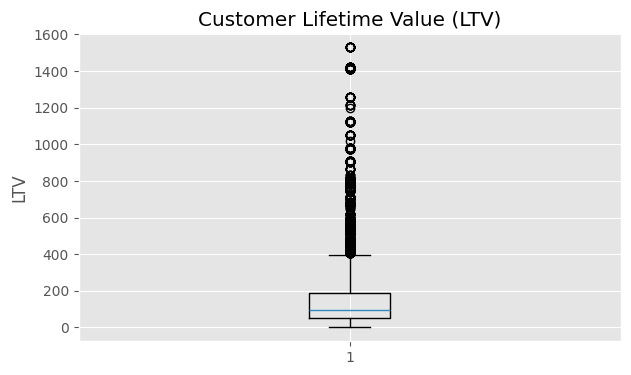

In [42]:
plt.figure(figsize=(7,4))

plt.boxplot(purchase_df['ltv'])

plt.title("Customer Lifetime Value (LTV)")

plt.ylabel("LTV")

plt.show()

### Observation

The distribution of Customer Lifetime Value (LTV) shows variation across customers, with a few customers having much higher lifetime values.

### Business Insight

High-value customers should be retained through loyalty programmes and personalised marketing initiatives.

### Outlier Analysis

A box plot was used to identify potential outliers in Customer Lifetime Value (LTV). A few outliers were observed, representing customers with significantly higher lifetime values.

These observations were retained because they may represent high-value customers rather than data entry errors. Retaining such records provides a more realistic view of customer behaviour and business performance.

### Business Question 10

###Which customers have the highest Lifetime Value (LTV)?

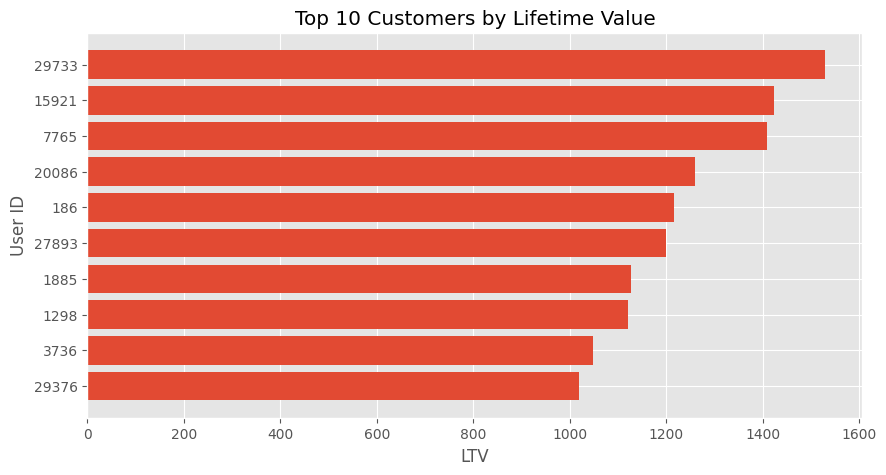

In [43]:
top_customers = (
    purchase_df.groupby('user_id')['ltv']
    .max()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(10,5))
plt.barh(top_customers.index.astype(str), top_customers.values)
plt.title("Top 10 Customers by Lifetime Value")
plt.xlabel("LTV")
plt.ylabel("User ID")
plt.gca().invert_yaxis()

plt.show()

### Observation

A small group of customers contributes significantly to the overall customer lifetime value.

### Business Insight

The company should focus on retaining these valuable customers through targeted offers and long-term engagement strategies.

### Business Question 11

###On which day are the most purchases made?

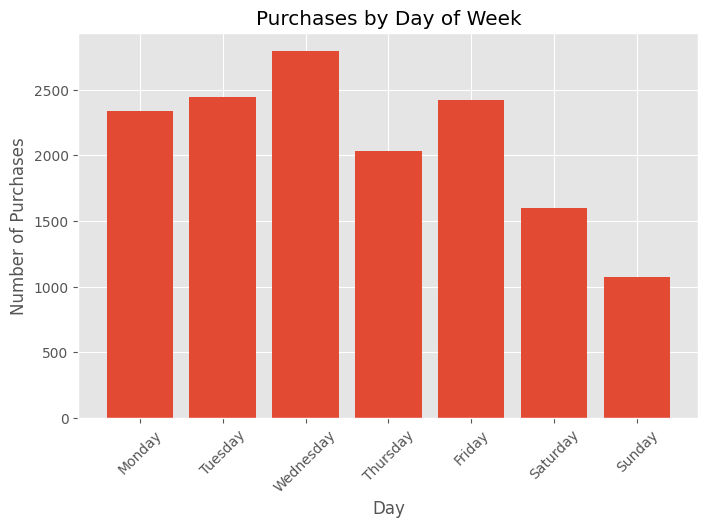

In [44]:
day_order = [
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday','Saturday','Sunday'
]
day_sales = (
    purchase_df['Day']
    .value_counts()
    .reindex(day_order)
)
plt.figure(figsize=(8,5))
plt.bar(day_sales.index, day_sales.values)
plt.title("Purchases by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=45)

plt.show()

### Business Question 12

### Is there any relationship between product price and customer Lifetime Value (LTV)?

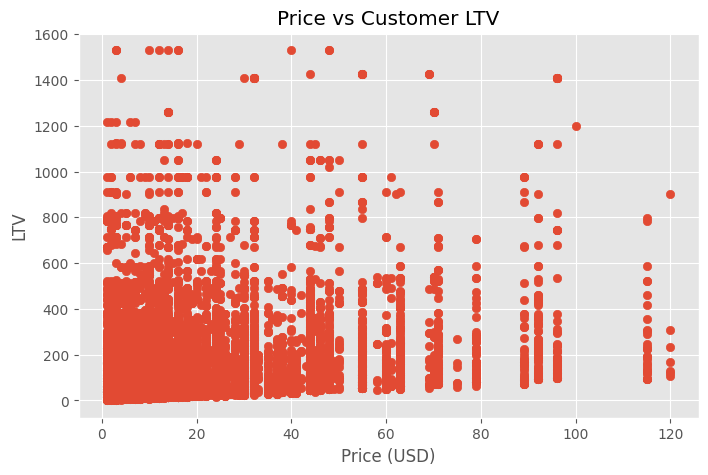

In [45]:
plt.figure(figsize=(8,5))
plt.scatter(
    purchase_df['price_in_usd'],
    purchase_df['ltv']
)
plt.title("Price vs Customer LTV")
plt.xlabel("Price (USD)")
plt.ylabel("LTV")

plt.show()

### Observation

The scatter plot shows that there is no strong linear relationship between product price and customer lifetime value (LTV). Customers purchasing higher-priced products do not always have higher lifetime values.

### Business Insight

The business should focus on improving customer engagement and retention strategies rather than relying only on higher product prices to increase customer lifetime value.

###Business Question 13

Is there a significant relationship between the numerical variables in the dataset?

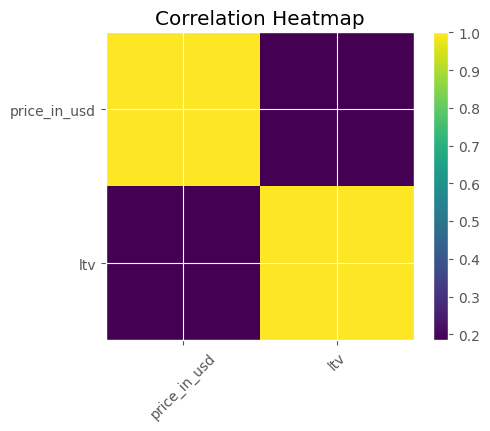

In [49]:
corr = purchase_df[['price_in_usd', 'ltv']].corr()

plt.figure(figsize=(5,4))

plt.imshow(corr)

plt.xticks([0,1], corr.columns, rotation=45)
plt.yticks([0,1], corr.columns)

plt.colorbar()

plt.title("Correlation Heatmap")

plt.show()

### Correlation Interpretation

The correlation heatmap shows the relationship between the numerical variables in the dataset. A weak positive correlation is observed between Product Price and Customer Lifetime Value (LTV), indicating that higher product prices do not necessarily lead to higher customer lifetime value.

### Business Insight

The business should not rely solely on product pricing to improve customer lifetime value. Customer retention, purchase frequency, and personalised marketing strategies are likely to have a greater impact on long-term business growth.

#12. Descriptive Statistics

Descriptive statistics summarise the key characteristics of numerical variables in the dataset. They provide information about the central tendency, spread, and distribution of the data.

In [50]:
purchase_df[['price_in_usd','ltv']].describe()

,price_in_usd,ltv
count,14711.000000,14711.000000
mean,19.672830,156.609476
std,18.619906,181.489643
min,1.000000,1.000000
25%,7.000000,50.000000
50%,14.000000,96.000000
75%,24.000000,188.000000
max,120.000000,1530.000000


In [51]:
purchase_df[['price_in_usd','ltv']].agg(
    ['mean','median','min','max','std']
)

,price_in_usd,ltv
mean,19.672830,156.609476
median,14.000000,96.000000
min,1.000000,1.000000
max,120.000000,1530.000000
std,18.619906,181.489643


### Statistical Interpretation

The descriptive statistics provide an overview of the numerical variables.

- The mean represents the average value.
- The median indicates the central value of the data.
- The standard deviation measures variability.
- The minimum and maximum values show the overall data range.
- Higher maximum values indicate the presence of high-value transactions and customers.

In [52]:
purchase_df[['price_in_usd','ltv']].skew()

,0
price_in_usd,1.845395
ltv,3.144487


### Skewness Analysis

The skewness values indicate that the numerical variables are not perfectly symmetric. A positive skew suggests that a small number of customers or products have significantly higher values than the majority.

In [53]:
purchase_df[['price_in_usd','ltv']].kurt()

,0
price_in_usd,4.158019
ltv,13.363064


### Kurtosis Analysis

The kurtosis values indicate the presence of extreme observations within the dataset. Such observations may represent high-value customers or premium products rather than data errors.

#**KPI Summary**

In [54]:
print("Total Revenue :", purchase_df['price_in_usd'].sum())

print("Average Price :", round(purchase_df['price_in_usd'].mean(),2))

print("Average LTV :", round(purchase_df['ltv'].mean(),2))

print("Highest Product Price :", purchase_df['price_in_usd'].max())

print("Lowest Product Price :", purchase_df['price_in_usd'].min())

print("Unique Customers :", purchase_df['user_id'].nunique())

print("Unique Products :", purchase_df['item_id'].nunique())

print("Countries :", purchase_df['country'].nunique())

Total Revenue : 289407
Average Price : 19.67
Average LTV : 156.61
Highest Product Price : 120
Lowest Product Price : 1
Unique Customers : 4066
Unique Products : 809
Countries : 100


#13. Key Findings

1. The highest revenue was generated by a limited number of products.
2. A few product categories contributed significantly to total revenue.
3. Most purchases were made using a specific device.
4. Customer Lifetime Value varies across customers, indicating the presence of high-value customers.
5. Certain countries contributed more purchases than others.
6. Product pricing shows noticeable variation across categories.

#14. Business Recommendations

1. Increase marketing investment for top-performing products.

2. Maintain sufficient inventory for high-revenue categories.

3. Focus promotional campaigns on countries with higher customer activity.

4. Improve customer retention through loyalty and reward programs.

5. Enhance user experience across frequently used devices.

6. Analyse customer behaviour regularly to identify changing purchasing trends.

7. Use customer segmentation for personalised marketing campaigns.

8. Continue monitoring business KPIs to support data-driven decision-making.

#15. Conclusion

This project successfully analysed the Google Merchandise Store dataset using Python.

The analysis included data understanding, cleaning, preprocessing, feature engineering, descriptive statistics, and exploratory data analysis.

Multiple visualisations were created to analyse customer purchasing behaviour, product performance, sales trends, device usage, country-wise purchases, and customer lifetime value.

The insights generated from this project can help businesses improve marketing strategies, inventory planning, customer retention, and overall business performance through data-driven decision-making.

#16. Project Limitations

- The analysis is based only on the available dataset.
- The project focuses on exploratory data analysis (EDA).
- Additional business data could provide deeper insights.

#17. Future Scope

The project can be extended by:

- Building an interactive Power BI dashboard.
- Performing SQL-based business analysis.
- Developing sales forecasting models.
- Applying customer segmentation techniques.
- Creating recommendation systems.
- Analysing customer retention and repeat purchases.

Thank You